# ***Dataset SetUp And Download***

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makes charts look a bit nicer by default
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
!pip install yfinance -q

import yfinance as yf

df = yf.download("AAPL", period="5y")
df = df.reset_index()
df.to_csv("AAPL.csv")
df.head()

/tmp/ipykernel_15372/3535772868.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", period="5y")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2021-07-21,141.728943,142.440523,140.978394,141.855665,74993500
1,2021-07-22,143.093567,144.458213,142.128557,142.255280,77338200
2,2021-07-23,144.809143,144.965107,143.210551,143.824649,71447400
3,2021-07-26,145.228302,146.047090,143.970864,144.526479,72434100
4,2021-07-27,143.064331,145.442728,141.875133,145.354989,104818600


# ***Exploration***

In [ ]:
# Shape = (number of rows, number of columns)
print("Shape:", df.shape)

# Column names and their data types
df.info()

Shape: (1255, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1255 non-null   datetime64[ns]
 1   (Close, AAPL)   1255 non-null   float64       
 2   (High, AAPL)    1255 non-null   float64       
 3   (Low, AAPL)     1255 non-null   float64       
 4   (Open, AAPL)    1255 non-null   float64       
 5   (Volume, AAPL)  1255 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.0 KB


In [ ]:
# Basic statistics: mean, min, max, std deviation, etc. for numeric columns
df.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
count,1255,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,2024-01-17 15:54:38.725099520,195.652733,197.604688,193.521957,195.448191,6.478512e+07
min,2021-07-21 00:00:00,122.933540,125.637646,122.097746,123.907026,7.250512e+06
25%,2022-10-17 12:00:00,158.269684,159.980849,155.970280,157.779530,4.566225e+07
50%,2024-01-18 00:00:00,184.106003,185.493171,182.038160,184.007144,5.674310e+07
75%,2025-04-19 00:00:00,227.689156,230.118043,225.717961,227.613748,7.652195e+07
max,2026-07-21 00:00:00,333.739990,334.989990,329.000000,333.510010,3.186799e+08
std,NaN,46.285004,46.664043,45.867318,46.234535,2.857641e+07


In [ ]:
# Count missing values per column
df.isnull().sum()

,,0
Price,Ticker,
Date,,0
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


# ***Data Cleaning & Preprocessing***

In [ ]:
# Convert 'Date' column to real datetime objects (not just text)
df['Date'] = pd.to_datetime(df['Date'])

# Sort chronologically (oldest to newest) - important for time-series work
df = df.sort_values('Date').reset_index(drop=True)

# Drop any fully duplicate rows, just in case
df = df.drop_duplicates()

# Handle missing values:
# forward-fill uses the previous valid value to fill a gap (common for price data)
df = df.ffill()

# Set Date as the index - this unlocks a lot of pandas' time-series features
df = df.set_index('Date')

print("Missing values after cleaning:\n", df.isnull().sum())
df.head()

Missing values after cleaning:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-07-21,141.728943,142.440523,140.978394,141.855665,74993500
2021-07-22,143.093567,144.458213,142.128557,142.255280,77338200
2021-07-23,144.809143,144.965107,143.210551,143.824649,71447400
2021-07-26,145.228302,146.047090,143.970864,144.526479,72434100
2021-07-27,143.064331,145.442728,141.875133,145.354989,104818600


# ***Data Transformation With Pandas***

In [ ]:
# --- Calculated column example ---
# Daily trading range = how much the price moved within a single day
df['Daily_Range'] = df['High'] - df['Low']

df[['Open', 'High', 'Low', 'Close', 'Daily_Range']].head()

Price,Open,High,Low,Close,Daily_Range
Ticker,AAPL,AAPL,AAPL,AAPL,
Date,,,,,
2021-07-21,141.855665,142.440523,140.978394,141.728943,1.462128
2021-07-22,142.255280,144.458213,142.128557,143.093567,2.329656
2021-07-23,143.824649,144.965107,143.210551,144.809143,1.754556
2021-07-26,144.526479,146.047090,143.970864,145.228302,2.076226
2021-07-27,145.354989,145.442728,141.875133,143.064331,3.567595


In [ ]:
# --- Filtering example ---
# Keep only the most recent 1 year of data
last_year = df[df.index >= (df.index.max() - pd.DateOffset(years=1))]
print("Rows in the last 1 year:", len(last_year))
last_year.head()


Rows in the last 1 year: 252


Price,Close,High,Low,Open,Volume,Daily_Range
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2025-07-21,211.640366,214.927328,210.793734,211.261878,51377400,4.133595
2025-07-22,213.552795,214.100625,211.391372,212.297780,46404100,2.709253
2025-07-23,213.303787,214.299836,211.570673,214.150435,46989300,2.729163
2025-07-24,212.915298,214.837680,212.686212,213.054745,46022600,2.151468
2025-07-25,213.034851,214.389478,212.556737,213.851603,40268800,1.832741


In [ ]:
# --- Sorting example ---
# Find the 5 highest single-day trading volumes in the whole dataset
top_volume_days = df.sort_values(('Volume', 'AAPL'), ascending=False).head(5)
top_volume_days[[('Close', 'AAPL'), ('Volume', 'AAPL')]]

Price,Close,Volume
Ticker,AAPL,AAPL
Date,,
2024-09-20,226.502075,318679900
2026-06-26,283.779999,261775500
2024-06-21,205.708084,241805100
2024-06-12,211.240128,198134300
2021-12-17,167.312790,195432700


In [ ]:
# --- Grouping & aggregation example ---
# Average closing price per calendar year
yearly_avg_close = df.groupby(df.index.year)['Close'].mean()
yearly_avg_close


Price,Close
Ticker,AAPL
Date,
2021,149.984413
2022,151.805451
2023,170.194611
2024,205.457394
2025,231.349892
2026,277.601567


# ***Time-Series Analysis***

In [ ]:
# --- Monthly resampling ---
# 'ME' = Month End: takes the average of each column within each calendar month
monthly = df.resample('ME').mean(numeric_only=True)
monthly[['Close']].head()


Price,Close
Ticker,AAPL
Date,
2021-07-31,142.922993
2021-08-31,144.613964
2021-09-30,144.778336
2021-10-31,142.101190
2021-11-30,150.765307


In [ ]:
# --- Daily percentage change ---
# How much did the closing price change (%) from the previous trading day?
df['Daily_Pct_Change'] = df['Close'].pct_change() * 100

df[['Close', 'Daily_Pct_Change']].head(10)

Price,Close,Daily_Pct_Change
Ticker,AAPL,
Date,,
2021-07-21,141.728943,NaN
2021-07-22,143.093567,0.962841
2021-07-23,144.809143,1.198919
2021-07-26,145.228302,0.289456
2021-07-27,143.064331,-1.490048
2021-07-28,141.319489,-1.219621
2021-07-29,141.962875,0.455271
2021-07-30,142.177292,0.151037


In [ ]:
# --- Trend check ---
# Compare the first and last closing price to see overall direction
start_price = df['Close'].iloc[0]
end_price = df['Close'].iloc[-1]
overall_change_pct = ((end_price - start_price) / start_price) * 100

print(f"Start price: {start_price.item():.2f}")
print(f"End price:   {end_price.item():.2f}")
print(f"Overall change over the period: {overall_change_pct.item():.2f}%")

Start price: 141.73
End price:   324.74
Overall change over the period: 129.13%


# ***Visualizations***

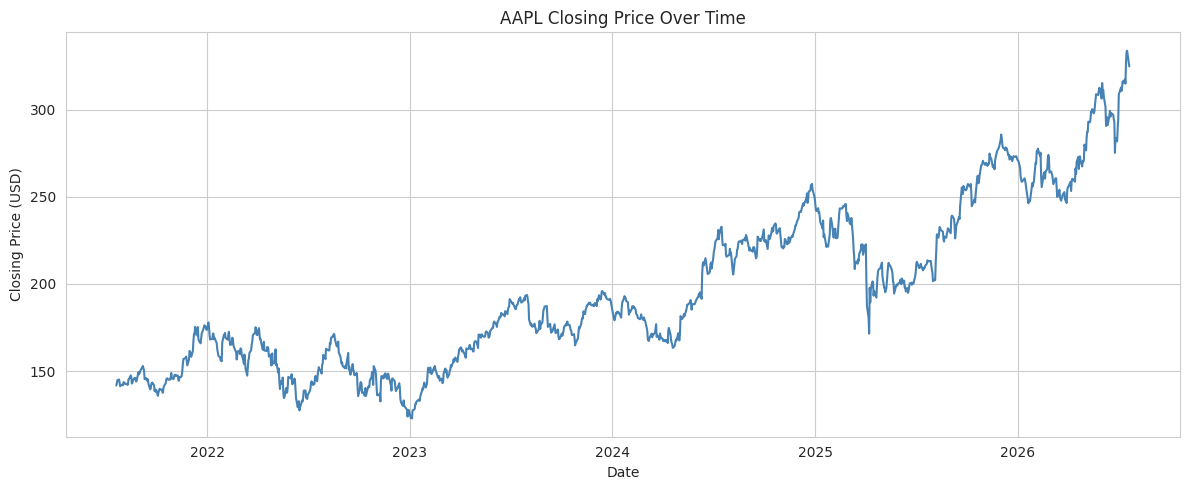

In [ ]:
# 1. Stock Closing Price Trend
plt.figure()
plt.plot(df.index, df['Close'], color='steelblue')
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.tight_layout()
plt.show()

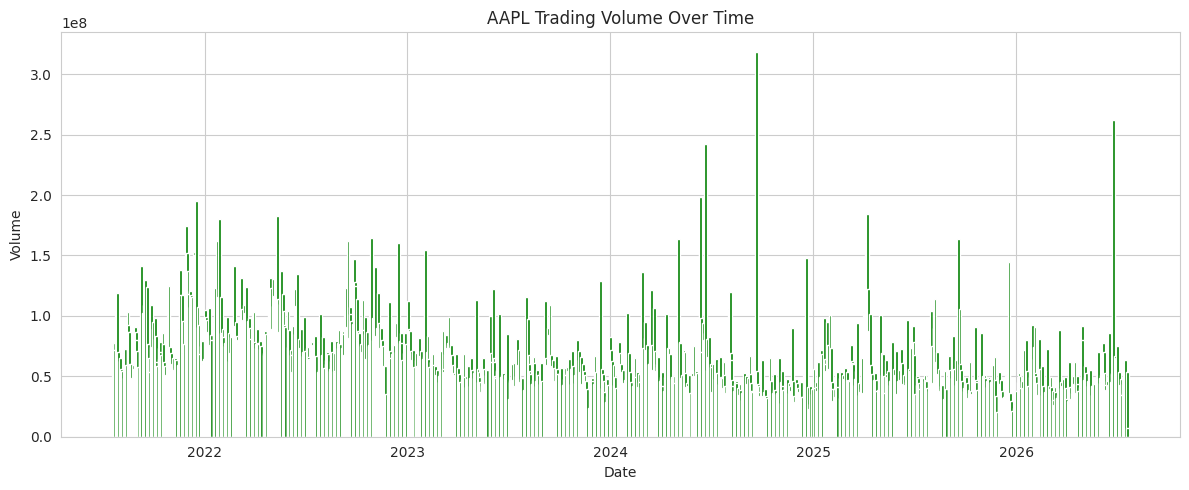

In [ ]:
# 2. Trading Volume Trend
plt.figure()
plt.bar(df.index, df[('Volume', 'AAPL')], color='green', width=5)
plt.title('AAPL Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

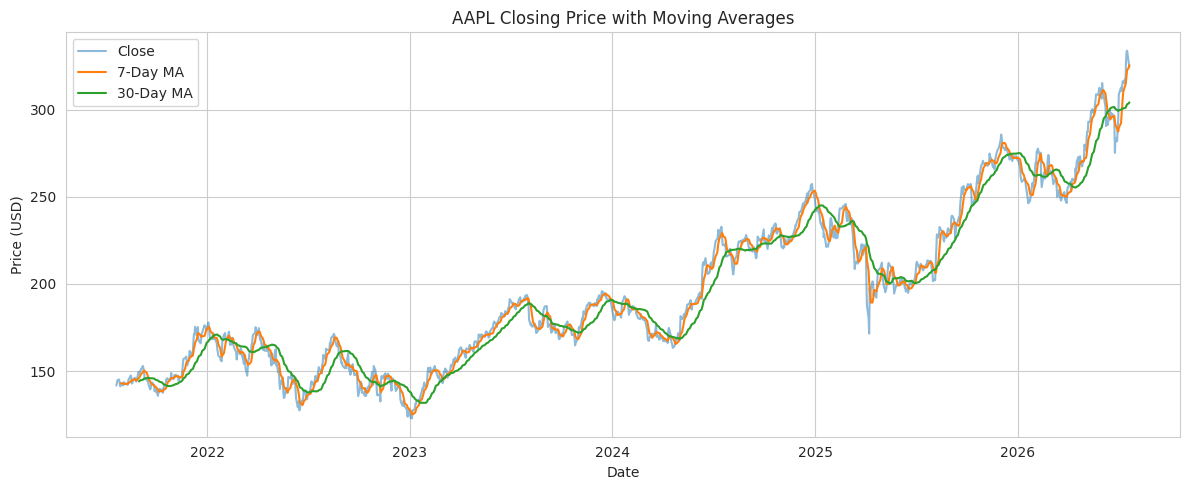

In [ ]:
# 3. Moving Average Analysis

# Calculate moving averages
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

plt.figure()
plt.plot(df.index, df['Close'], label='Close', alpha=0.5)
plt.plot(df.index, df['MA_7'], label='7-Day MA')
plt.plot(df.index, df['MA_30'], label='30-Day MA')
plt.title('AAPL Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

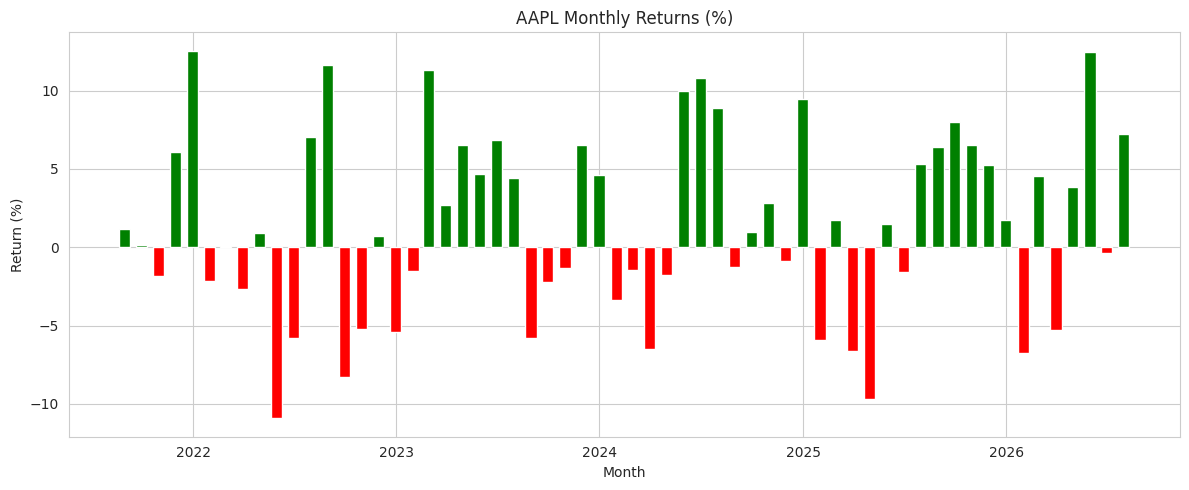

In [ ]:
# 4. Monthly Returns Analysis
# Calculate monthly returns
monthly_returns = monthly['Close'].pct_change() * 100

plt.figure()
# Access the first (and only) column's values from the DataFrame
colors = ['green' if x >= 0 else 'red' for x in monthly_returns.iloc[:, 0].fillna(0)]
plt.bar(monthly_returns.index, monthly_returns.iloc[:, 0].values, color=colors, width=20)
plt.title('AAPL Monthly Returns (%)')
plt.xlabel('Month')
plt.ylabel('Return (%)')
plt.tight_layout()
plt.show()

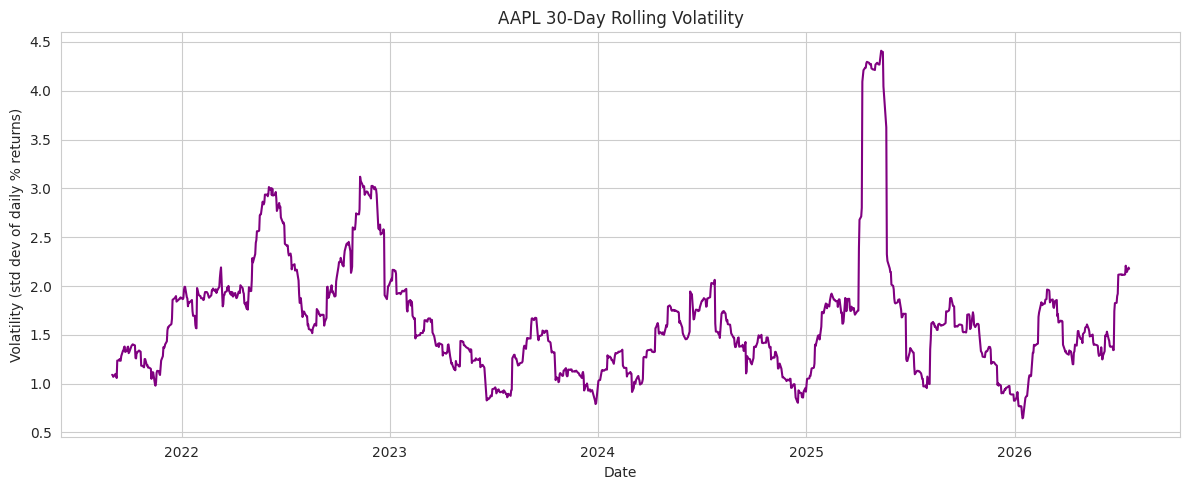

In [ ]:
# Bonus: Volatility over time
# Calculate 30-day rolling volatility (standard deviation of daily percentage returns)
df['Volatility_30D'] = df['Daily_Pct_Change'].rolling(window=30).std()

plt.figure()
plt.plot(df.index, df['Volatility_30D'], color='purple')
plt.title('AAPL 30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (std dev of daily % returns)')
plt.tight_layout()
plt.show()

# ***Feature Engineering***

In [ ]:
# Daily price change in dollars (today's close minus yesterday's close)
df['Daily_Price_Change'] = df['Close'].diff()

# 7-day and 30-day simple moving averages (smooths out daily noise)
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

df[['Close', 'Daily_Price_Change', 'MA_7', 'MA_30']].tail(10)

Price,Close,Daily_Price_Change,MA_7,MA_30
Ticker,AAPL,,,
Date,,,,
2026-07-08,313.390015,2.730011,NaN,NaN
2026-07-09,316.220001,2.829987,NaN,NaN
2026-07-10,315.320007,-0.899994,NaN,NaN
2026-07-13,317.309998,1.989990,NaN,NaN
2026-07-14,314.859985,-2.450012,NaN,NaN
2026-07-15,327.500000,12.640015,NaN,NaN
2026-07-16,333.260010,5.760010,NaN,NaN
2026-07-17,333.739990,0.479980,NaN,NaN


In [ ]:
# Monthly returns: % change from the start to the end of each calendar month
monthly_close = df[('Close', 'AAPL')].resample('ME').last()
monthly_returns = monthly_close.pct_change() * 100
monthly_returns = monthly_returns.rename('Monthly_Return_Pct') # This renames the Series name if monthly_returns is a Series
monthly_returns.tail(12)

,Monthly_Return_Pct
Date,
2025-08-31,11.963892
2025-09-30,9.688122
2025-10-31,6.181521
2025-11-30,3.236417
2025-12-31,-2.506729
2026-01-31,-4.553809
2026-02-28,1.906580
2026-03-31,-3.932929
2026-04-30,6.919120


In [ ]:
# Volatility: rolling 30-day standard deviation of daily % returns
# A rolling standard deviation tells us how much the returns are swinging around,
# which is a common proxy for risk.
df['Volatility_30D'] = df['Daily_Pct_Change'].rolling(window=30).std()

df[['Daily_Pct_Change', 'Volatility_30D']].tail(10)

Price,Daily_Pct_Change,Volatility_30D
Ticker,,
Date,,
2026-07-08,0.878778,2.112708
2026-07-09,0.903024,2.117620
2026-07-10,-0.284610,2.114412
2026-07-13,0.631102,2.115222
2026-07-14,-0.772119,2.120542
2026-07-15,4.014487,2.207953
2026-07-16,1.758782,2.170076
2026-07-17,0.144026,2.144118


# ***Key Findings & Conclusions***

### **Key Findings**:

1.  **Overall Price Appreciation:** Over the 5-year period analyzed (from July 2021 to July 2026), AAPL has shown significant growth, with an overall price change of approximately **129.13%**. This indicates a strong upward trend in the stock's value.

2.  **Moving Average Support:** The 7-day and 30-day moving averages largely followed the closing price trend. Sustained periods where the price remains above these moving averages indicate bullish sentiment, while drops below them can signal potential short-term weaknesses or corrections.

3.  **Monthly Returns Volatility:** Monthly returns varied, with both positive and negative months. The bar chart of monthly returns visually highlights periods of strong gains (green) and losses (red), which is typical for equity markets.

4.  **Trading Volume Peaks:** Certain days exhibited exceptionally high trading volumes (e.g., September 20, 2024, and June 26, 2026). These high-volume days often coincide with significant news events, earnings releases, or major price movements, suggesting increased market activity and interest during those times.

5.  **Rolling Volatility Trends:** The 30-day rolling volatility showed periods of higher and lower price fluctuations. High volatility suggests greater risk but also potentially higher reward, while lower volatility indicates a more stable price environment.

6.  **Data Quality:** The dataset was clean with no missing values after preprocessing, ensuring the reliability of our analysis.


### **Recommendations**

1.  **Trend Following:** Given the strong overall upward trend, consider a strategy that leans into the long-term bullish movement, potentially using moving averages as indicators for entry and exit points.

2.  **Volatility Management:** For investors sensitive to risk, periods of high 30-day rolling volatility might suggest a need for caution or a reduction in position size. Conversely, higher volatility could present opportunities for short-term traders.

3.  **Event-Driven Analysis:** Investigate the specific events corresponding to the highest trading volume days. Understanding why these spikes occurred can provide insights into market catalysts and potential future drivers for the stock.

4.  **Diversification:** While AAPL has performed well, it's crucial to remember that past performance is not indicative of future results. Diversifying across different assets and sectors can help mitigate risks associated with single-stock exposure.

5.  **Further Technical Analysis:** Explore additional technical indicators (e.g., RSI, MACD, Bollinger Bands) to get a more comprehensive view of price momentum and potential overbought/oversold conditions.

6.  **Fundamental Analysis:** Complement this technical analysis with fundamental research on Apple's financial health, product pipeline, market share, and competitive landscape to make well-rounded investment decisions.